# 1.IMPORTING LIBRARIES

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.model_selection import RandomizedSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

# 2.LOADING DATA

In [5]:
train=pd.read_csv("HR_train.csv")
test=pd.read_csv("HR_test.csv")

In [6]:
train.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7352 entries, 0 to 7351
Columns: 563 entries, tBodyAcc-mean()-X to Activity
dtypes: float64(561), int64(1), object(1)
memory usage: 31.6+ MB


In [8]:
train.subject.value_counts()   #counts unique value in subject coloumns

subject
25    409
21    408
26    392
30    383
28    382
27    376
23    372
17    368
16    366
19    360
1     347
29    344
3     341
15    328
6     325
14    323
22    321
11    316
7     308
5     302
8     281
Name: count, dtype: int64

# 3.DATA PROCESSING

## a.CHECKING DUPLICATES

In [11]:
print("train:",sum(train.duplicated()))

print("test:",sum(test.duplicated()))

train: 0
test: 0


## b.checking for missing values

In [13]:
print("test:",train.isna().values.sum())
print("test:",test.isna().values.sum())

test: 0
test: 0


## c.Checking for class inbalance

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'LAYING'),
  Text(1, 0, 'STANDING'),
  Text(2, 0, 'SITTING'),
  Text(3, 0, 'WALKING'),
  Text(4, 0, 'WALKING_UPSTAIRS'),
  Text(5, 0, 'WALKING_DOWNSTAIRS')])

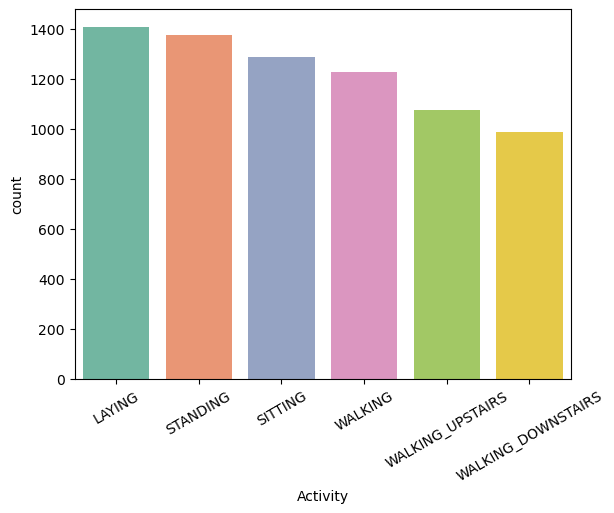

In [51]:
sns.countplot(x=train.Activity,palette="Set2",order=train.Activity.value_counts().index)
plt.xticks(rotation=30)

## 4.EDA

### TYPES OF FEATURES

In [83]:
pd.DataFrame.from_dict(Counter([col.split("-")[0].split('(')[0] for col in train.columns]),orient="index").rename(columns={0:"count"}).sort_values('count',ascending=False)

,count
fBodyAcc,79
fBodyGyro,79
fBodyAccJerk,79
tGravityAcc,40
tBodyAcc,40
tBodyGyroJerk,40
tBodyGyro,40
tBodyAccJerk,40
tBodyAccMag,13
tGravityAccMag,13


### 4a.Analysing tBodyAccMag-mean feature

<function matplotlib.pyplot.annotate(text: 'str', xy: 'tuple[float, float]', xytext: 'tuple[float, float] | None' = None, xycoords: 'str | Artist | Transform | Callable[[RendererBase], Bbox | Transform] | tuple[float, float]' = 'data', textcoords: 'str | Artist | Transform | Callable[[RendererBase], Bbox | Transform] | tuple[float, float] | None' = None, arrowprops: 'dict[str, Any] | None' = None, annotation_clip: 'bool | None' = None, **kwargs) -> 'Annotation'>

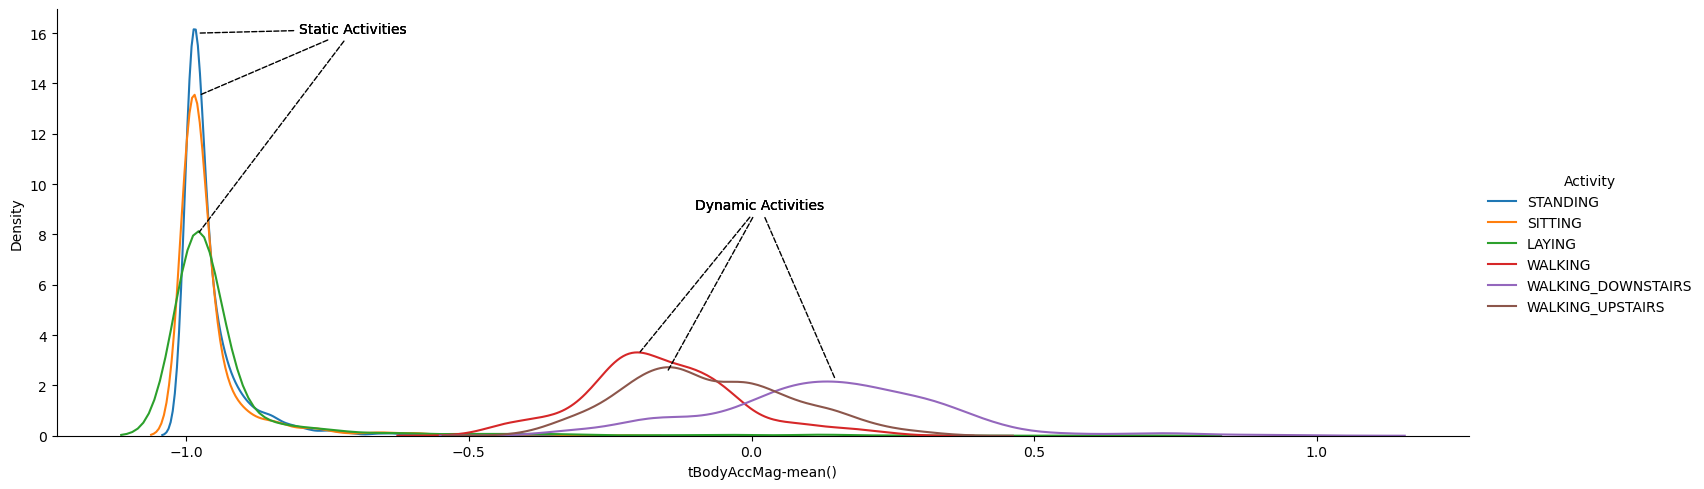

In [146]:
facetgrid=sns.FacetGrid(train,hue="Activity",height=5,aspect=3)
facetgrid.map(sns.distplot,'tBodyAccMag-mean()',hist=False).add_legend()

plt.annotate("Static Activities",xy=(-0.98,8),xytext=(-.8,16),arrowprops={'arrowstyle':'-','ls':'dashed'})
plt.annotate("Static Activities",xy=(-.98,13.5),xytext=(-.8,16),arrowprops={'arrowstyle':'-','ls':'dashed'})
plt.annotate("Static Activities",xy=(-.98,16),xytext=(-.8,16),arrowprops={'arrowstyle':'-','ls':'dashed'})

plt.annotate("Dynamic Activities",xy=(-.2,3.25),xytext=(-.1,9),arrowprops={'arrowstyle':'-','ls':'dashed'})
plt.annotate("Dynamic Activities",xy=(-.15,2.5),xytext=(-.1,9),arrowprops={'arrowstyle':'-','ls':'dashed'})
plt.annotate("Dynamic Activities",xy=(.15,2.15),xytext=(-.1,9),arrowprops={'arrowstyle':'-','ls':'dashed'})


plt.annotate

Text(0.5, 1.0, 'Boxplot of tBodyAccMag-mean() coloumns across various activities')

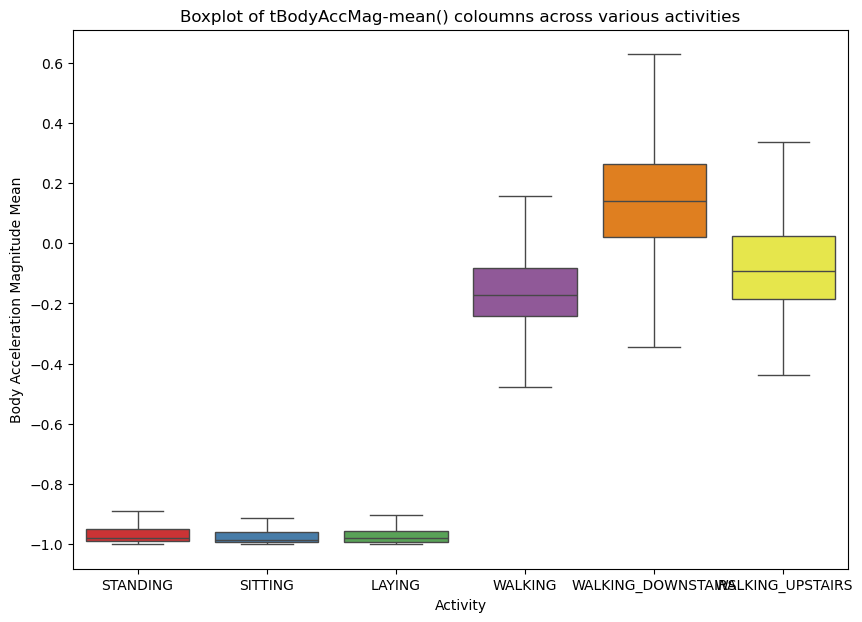

In [98]:
plt.figure(figsize=(10,7))
sns.boxplot(x="Activity",y="tBodyAccMag-mean()",data=train,showfliers=False,palette="Set1")
plt.ylabel("Body Acceleration Magnitude Mean")
plt.title("Boxplot of tBodyAccMag-mean() coloumns across various activities")

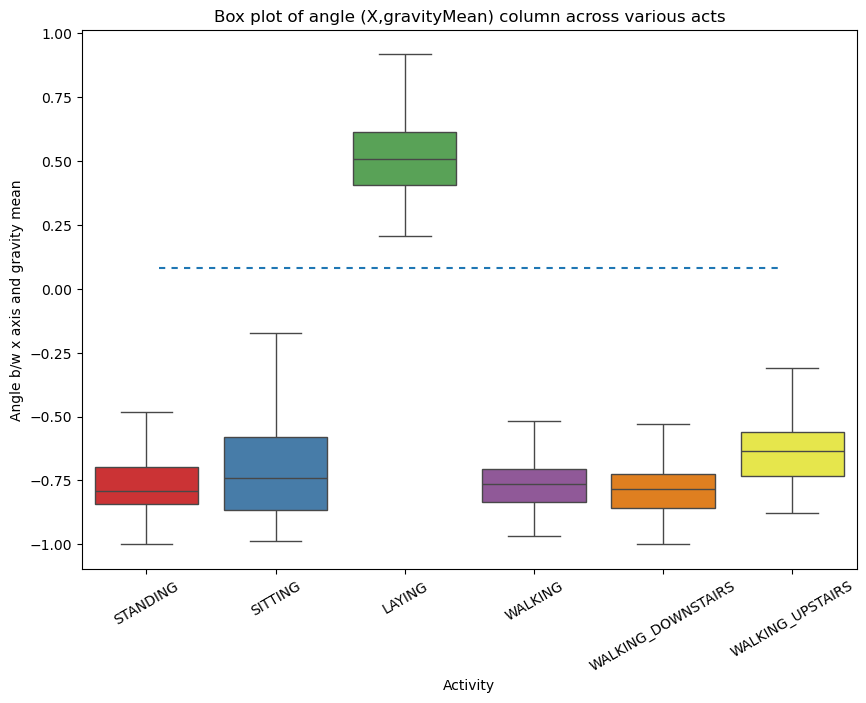

In [158]:
plt.figure(figsize=(10,7))
sns.boxplot(x='Activity',y='angle(X,gravityMean)',data=train,showfliers=False,palette='Set1')
plt.axhline(y=0.08,xmin=0.1,xmax=0.9,dashes=(3,3))
plt.ylabel("Angle b/w x axis and gravity mean")
plt.title("Box plot of angle (X,gravityMean) column across various acts")
plt.xticks(rotation =30)
plt.show()

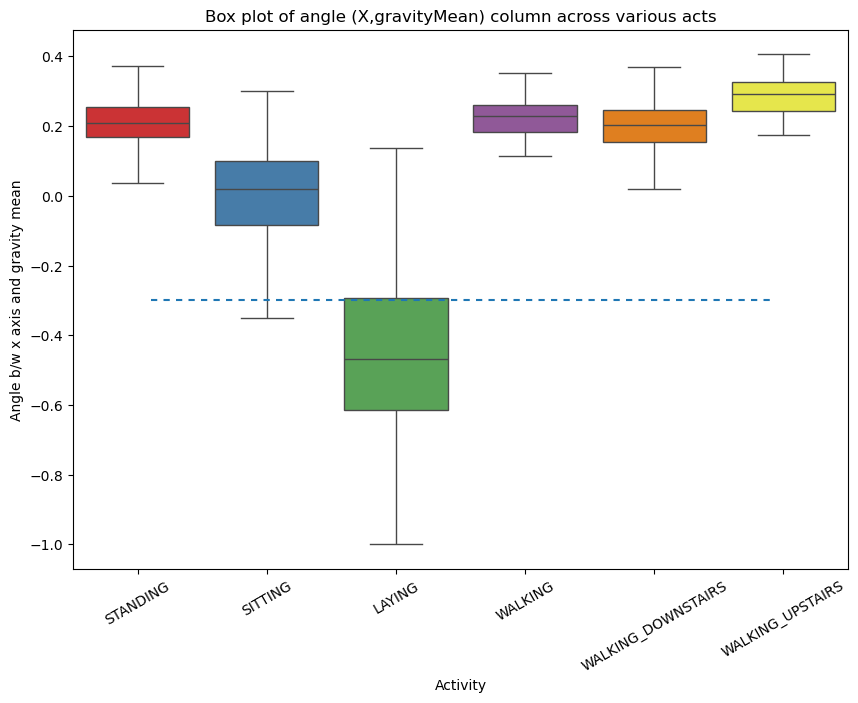

In [166]:
plt.figure(figsize=(10,7))
sns.boxplot(x='Activity',y='angle(Y,gravityMean)',data=train,showfliers=False,palette='Set1')
plt.axhline(y=-0.3,xmin=0.1,xmax=0.9,dashes=(3,3))
plt.ylabel("Angle b/w x axis and gravity mean")
plt.title("Box plot of angle (X,gravityMean) column across various acts")
plt.xticks(rotation =30)
plt.show()

## 4.D Visualising data using PCA

In [170]:
x_for_pca=train.drop(['subject','Activity'],axis=1)
pca=PCA(n_components=2,random_state=0).fit_transform(x_for_pca)

In [172]:
pca

array([[-5.5202803 , -0.29027701],
       [-5.53534954, -0.08253011],
       [-5.47498801,  0.28738703],
       ...,
       [ 5.85750527, -3.08184312],
       [ 5.42109482, -3.42643002],
       [ 5.49797027, -2.78992867]])

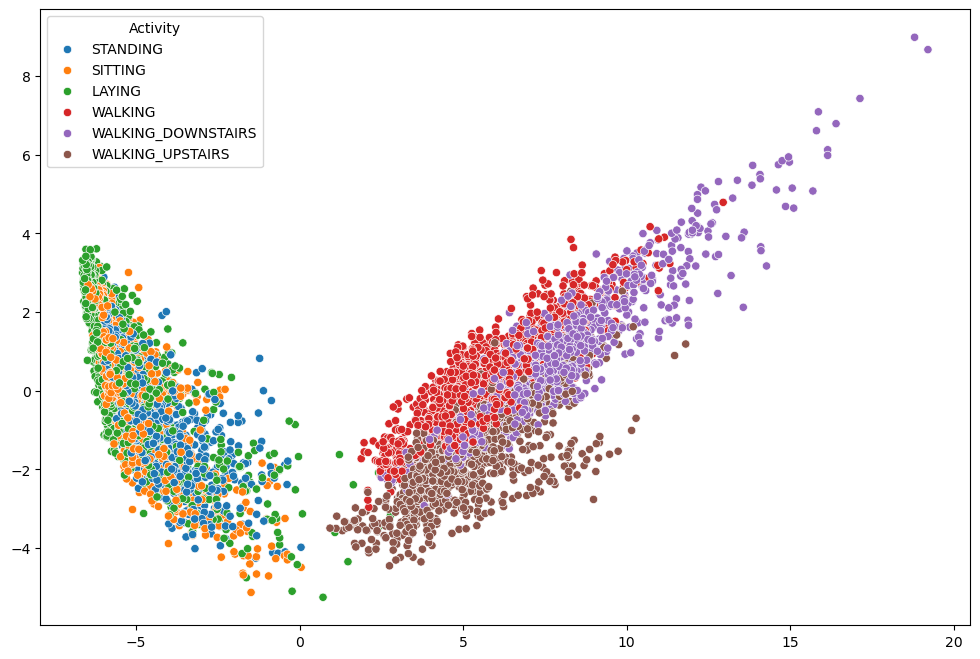

In [188]:
plt.figure(figsize=(12,8))
sns.scatterplot(x=pca[:,0],y=pca[:,1],hue=train["Activity"])
plt.show()

## 4.E Analysing Data using TSNE

In [199]:
x_for_tsne=train.drop(['subject','Activity'],axis=1)
tsne=TSNE(n_components=2,random_state=0,n_iter=1000).fit_transform(x_for_tsne)

In [200]:
tsne

array([[ -6.9932804, -63.188377 ],
       [-25.07103  , -17.728373 ],
       [-27.199108 , -20.449244 ],
       ...,
       [ 23.136957 , -60.145756 ],
       [ 23.117773 , -59.890156 ],
       [ 23.605974 , -59.11817  ]], dtype=float32)

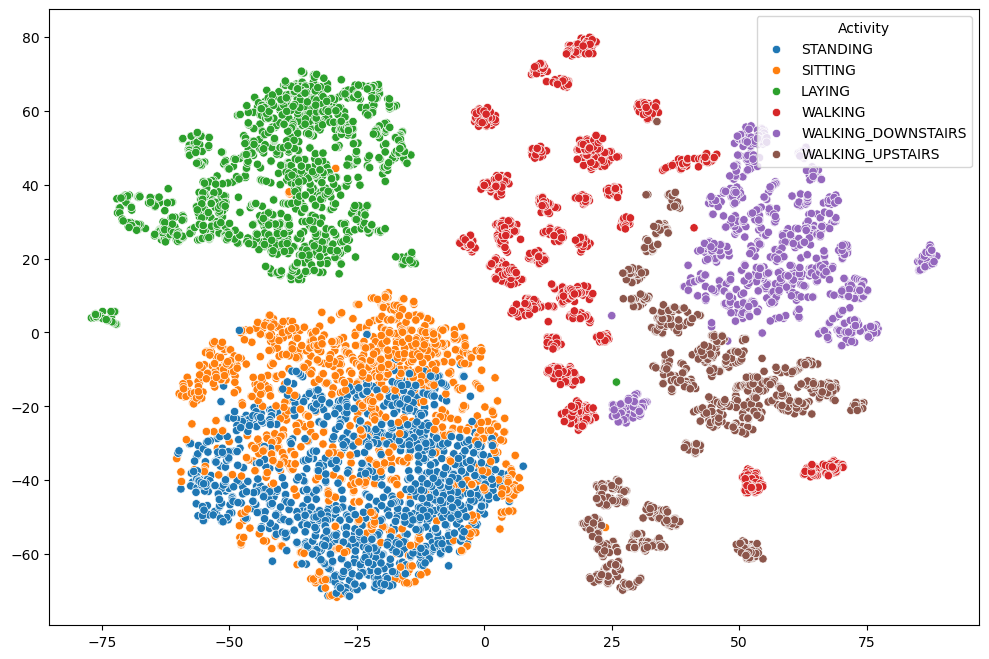

In [203]:
plt.figure(figsize=(12,8))
sns.scatterplot(x=tsne[:,0],y=tsne[:,1],hue=train["Activity"])
plt.show()

## 5.ML Models

## Getting trainig and testing data

In [211]:
x_train=train.drop(["Activity","subject"],axis=1)
y_train=train.Activity

x_test=test.drop(["Activity","subject"],axis=1)
y_test=test.Activity

In [217]:
print(x_train.shape)

print(x_test.shape)

(7352, 561)
(999, 561)


## 5a.Logistic Regression with hyperparameter tuning and cross validation

In [220]:
parameters={'max_iter':[100,200,500]}
lr_classifier=LogisticRegression()
lr_classifier_rs=RandomizedSearchCV(lr_classifier,param_distributions=parameters,cv=5,random_state=42)
lr_classifier_rs.fit(x_train,y_train)
y_pred_lr=lr_classifier_rs.predict(x_test)

In [222]:
lr_accuracy=accuracy_score(y_true=y_test,y_pred=y_pred_lr)
print("Acuuracy using logistic regression: ",lr_accuracy)

Acuuracy using logistic regression:  0.954954954954955


In [228]:
def plot_confusion_matrix(cm,labels):
    fig,ax=plt.subplots(figsize=(12,8))
    im=ax.imshow(cm,interpolation='nearest',cmap=plt.cm.Blues)
    ax.figure.colorbar(im,ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]),
          yticks=np.arange(cm.shape[0]),
          xticklabels=labels,yticklabels=labels,
          ylabel='True label',
          xlabel='Predicted label')
    plt.xticks(rotation=90)
    thresh=cm.max()/2
    for i in range(cm.shape[0]):
        for j in range (cm.shape[1]):
            ax.text(j,i,int(cm[i,j]),ha="center",va="center",color="white" if cm[i,j]>thresh else "black")
    fig.tight_layout()

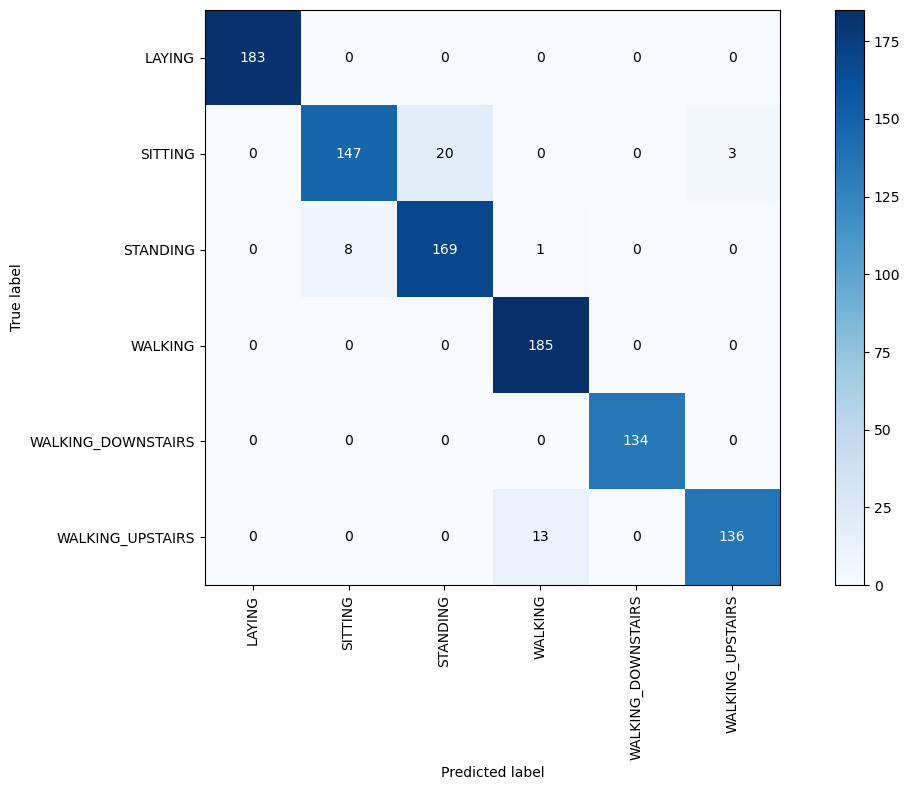

In [230]:
cm=confusion_matrix(y_test.values,y_pred_lr)
plot_confusion_matrix(cm,np.unique(y_pred_lr))

In [232]:
def get_best_randomsearch_results(model):
    print("Best estimator : ", model.best_estimator_)
    print("Best set of parameters : ", model.best_params_)
    #print("Best score : ", model.best_score_)

In [234]:
# getting best random search attributes
get_best_randomsearch_results(lr_classifier_rs)

Best estimator :  LogisticRegression(max_iter=500)
Best set of parameters :  {'max_iter': 500}


## 5.b Kernel SVM model with hyperparameter tuning cross validation

In [238]:
parameters={
    'kernel':['linear','rbf','poly','sigmoid'],
    'C':[100,50]
}

svm_rs=RandomizedSearchCV(SVC(),param_distributions=parameters,cv=3,random_state=42)
svm_rs.fit(x_train,y_train)

RandomizedSearchCV(cv=3, estimator=SVC(),
                   param_distributions={'C': [100, 50],
                                        'kernel': ['linear', 'rbf', 'poly',
                                                   'sigmoid']},
                   random_state=42)

In [240]:
y_pred=svm_rs.predict(x_test)

In [242]:
kernel_svm_accuracy=accuracy_score(y_true=y_test,y_pred=y_pred)
print("Accuracy using kernel SVM:",kernel_svm_accuracy)

Accuracy using kernel SVM: 0.965965965965966


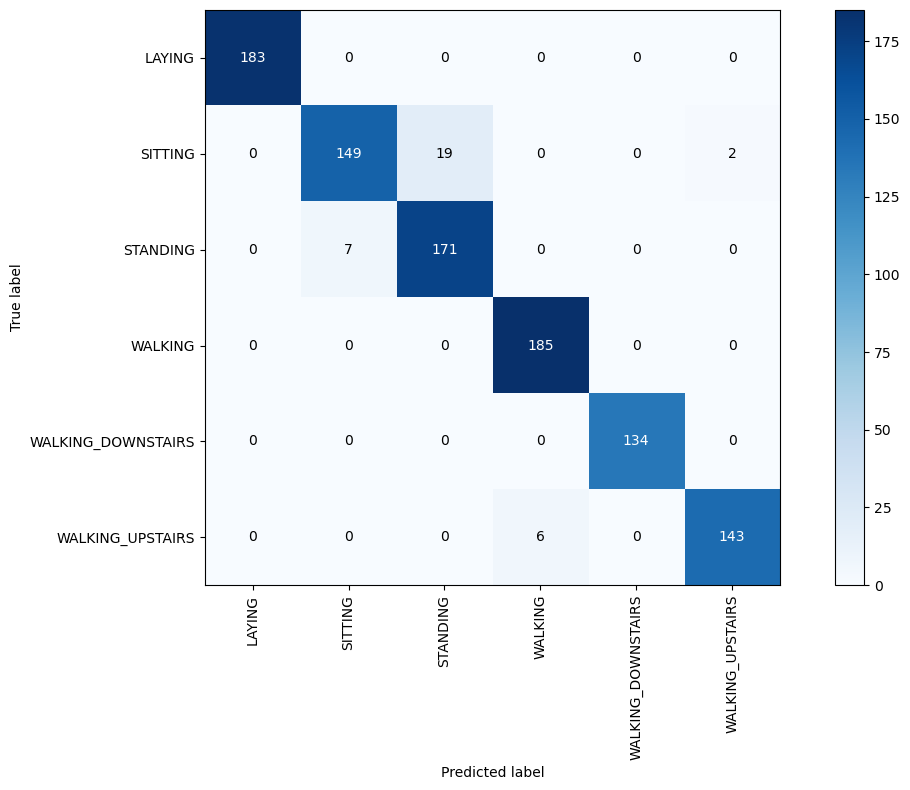

In [244]:
cm=confusion_matrix(y_test.values,y_pred)
plot_confusion_matrix(cm,np.unique(y_pred))

In [246]:
np.unique(y_pred)

array(['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS',
       'WALKING_UPSTAIRS'], dtype=object)

In [248]:
get_best_randomsearch_results(svm_rs)

Best estimator :  SVC(C=50)
Best set of parameters :  {'kernel': 'rbf', 'C': 50}


## 5.b Decission tree model with hyperparameter tuning cross validation

In [255]:
parameters={ 'max_depth':np.arange(2,10,2)}

dt_cls=DecisionTreeClassifier()
dt_cls_rs=RandomizedSearchCV(dt_cls,param_distributions=parameters,random_state=42)
dt_cls_rs.fit(x_train,y_train)

RandomizedSearchCV(estimator=DecisionTreeClassifier(),
                   param_distributions={'max_depth': array([2, 4, 6, 8])},
                   random_state=42)

In [257]:
y_pred=dt_cls_rs.predict(x_test)

In [271]:
dt_accuracy=accuracy_score(y_true=y_test,y_pred=y_pred)
print("Accuracy using Decision tree clasifier:",dt_accuracy)

Accuracy using Decision tree clasifier: 0.8488488488488488


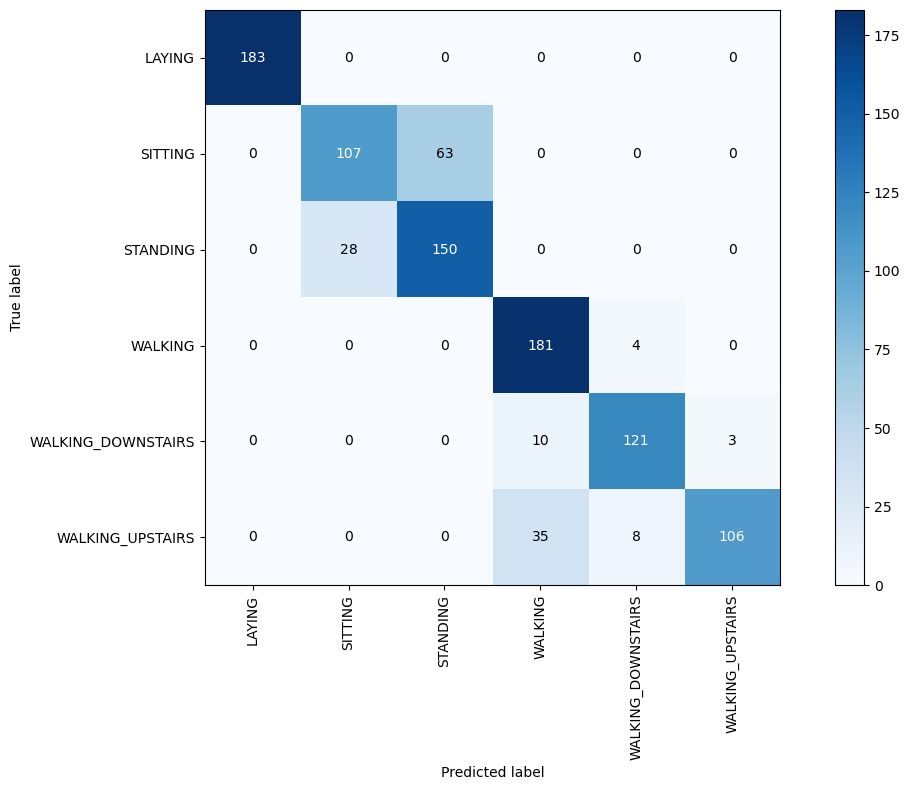

In [261]:
cm=confusion_matrix(y_test.values,y_pred)
plot_confusion_matrix(cm,np.unique(y_pred))

In [265]:
get_best_randomsearch_results(dt_cls_rs)

Best estimator :  DecisionTreeClassifier(max_depth=8)
Best set of parameters :  {'max_depth': 8}


## 5.b Random Forest model with hyperparameter tuning cross validation

In [269]:
parameters={
    'n_estimators':np.arange(20,101,10),
    'max_depth':np.arange(2,17,2)
}

rt_cls=RandomForestClassifier()
rt_cls_rs=RandomizedSearchCV(rt_cls,param_distributions=parameters,random_state=42)
rt_cls_rs.fit(x_train,y_train)

RandomizedSearchCV(estimator=RandomForestClassifier(),
                   param_distributions={'max_depth': array([ 2,  4,  6,  8, 10, 12, 14, 16]),
                                        'n_estimators': array([ 20,  30,  40,  50,  60,  70,  80,  90, 100])},
                   random_state=42)

In [273]:
y_pred=rt_cls_rs.predict(x_test)

In [275]:
rt_accuracy=accuracy_score(y_true=y_test,y_pred=y_pred)
print("Accuracy using Random Forest:",rt_accuracy)

Accuracy using Random Forest: 0.9159159159159159


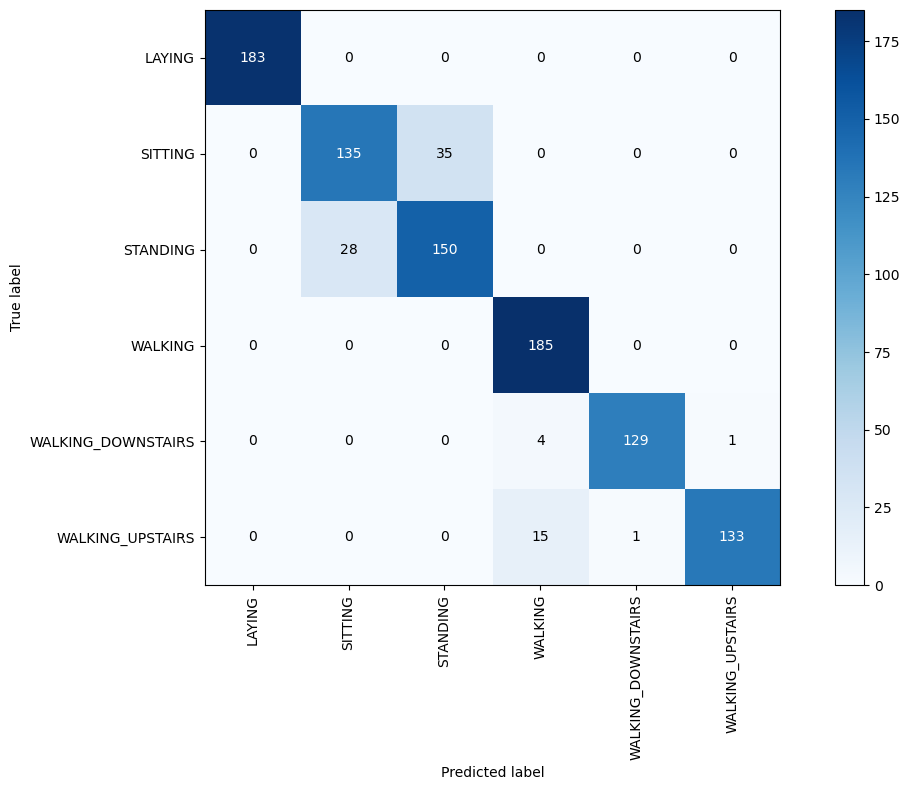

In [277]:
cm=confusion_matrix(y_test.values,y_pred)
plot_confusion_matrix(cm,np.unique(y_pred))

In [279]:
get_best_randomsearch_results(rt_cls_rs)

Best estimator :  RandomForestClassifier(max_depth=14)
Best set of parameters :  {'n_estimators': 100, 'max_depth': 14}
